# Problem 3: Low Autocorrelation Binary Sequences (LABS)

## Setup

In [1]:
import numpy as np
import time
import itertools
from typing import List, Tuple, Dict

# Set random seed for reproducibility
seed = 11202038  # Replace with your student ID
np.random.seed(seed)

print(f"Random seed: {seed}")

Random seed: 11202038


In [2]:
from pathlib import Path
import json

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_run_results(filename_stem, history=None, metadata=None, figure=None):
    payload = {}
    if history is not None:
        payload["history"] = [float(value) for value in history]
    if metadata is not None:
        payload.update(metadata)

    if payload:
        with open(RESULTS_DIR / f"{filename_stem}.json", "w", encoding="utf-8") as handle:
            json.dump(payload, handle, indent=2)

    if figure is not None:
        figure.savefig(RESULTS_DIR / f"{filename_stem}.png", dpi=300, bbox_inches="tight")

## Part (a): LABS Cost Function and Strategy Selection

First, implement the functions to calculate the LABS energy and merit factor. Verify your implementation using the Barker sequence of length N=11.

In [3]:
import numpy as np


def labs_cost_function(spins: np.ndarray) -> int:
    """Return the LABS sidelobe energy for a spin sequence in {+1, -1}."""
    spins = np.asarray(spins, dtype=np.int8)
    n = spins.size
    energy = 0
    for lag in range(1, n):
        autocorrelation = np.sum(spins[: n - lag] * spins[lag:])
        energy += int(autocorrelation * autocorrelation)
    return energy


def merit_factor(spins: np.ndarray) -> float:
    """Return the LABS merit factor F = N^2 / (2E)."""
    spins = np.asarray(spins, dtype=np.int8)
    energy = labs_cost_function(spins)
    if energy == 0:
        return np.inf
    n = spins.size
    return (n * n) / (2.0 * energy)


# Barker sequence of length 11 for a quick sanity check
barker_11 = np.array([1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1], dtype=np.int8)
barker_13 = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1], dtype=np.int8)
print("LABS energy:", labs_cost_function(barker_11))
print("Merit factor:", merit_factor(barker_11))
print("LABS energy:", labs_cost_function(barker_13))
print("Merit factor:", merit_factor(barker_13))

LABS energy: 5
Merit factor: 12.1
LABS energy: 6
Merit factor: 14.083333333333334


Testing QAOA optimization for N=5...
  Running with p=1 layers...
Final energy: 6.700110790837412
Best spin sequence: [ 1  1 -1  1  1]
LABS energy (best spins): 6
Merit factor (best spins): 2.0833333333333335
N_eval: 400
  Running with p=2 layers...
Final energy: 3.884291265383247
Best spin sequence: [ 1  1  1 -1  1]
LABS energy (best spins): 2
Merit factor (best spins): 6.25
N_eval: 400
  Running with p=3 layers...
Final energy: 2.012998599368686
Best spin sequence: [ 1  1  1 -1  1]
LABS energy (best spins): 2
Merit factor (best spins): 6.25
N_eval: 400
  Running with p=4 layers...
Final energy: 2.0000000000000187
Best spin sequence: [ 1  1  1 -1  1]
LABS energy (best spins): 2
Merit factor (best spins): 6.25
N_eval: 400


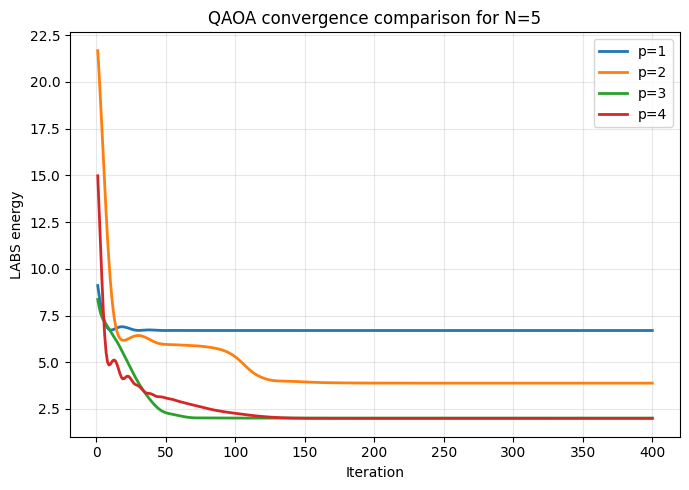

Testing QAOA optimization for N=11...
  Running with p=1 layers...
Final energy: 52.95776847984782
Best spin sequence: [ 1  1  1  1  1  1 -1 -1  1 -1  1]
LABS energy (best spins): 21
Merit factor (best spins): 2.880952380952381
N_eval: 400
  Running with p=2 layers...
Final energy: 51.38058435814018
Best spin sequence: [ 1  1  1 -1  1  1 -1 -1 -1  1 -1]
LABS energy (best spins): 37
Merit factor (best spins): 1.635135135135135
N_eval: 400
  Running with p=3 layers...
Final energy: 50.31336160628122
Best spin sequence: [ 1  1  1  1  1  1 -1  1 -1  1 -1]
LABS energy (best spins): 61
Merit factor (best spins): 0.9918032786885246
N_eval: 400
  Running with p=4 layers...
Final energy: 47.07156822970103
Best spin sequence: [ 1  1 -1 -1  1 -1  1  1 -1 -1 -1]
LABS energy (best spins): 37
Merit factor (best spins): 1.635135135135135
N_eval: 400


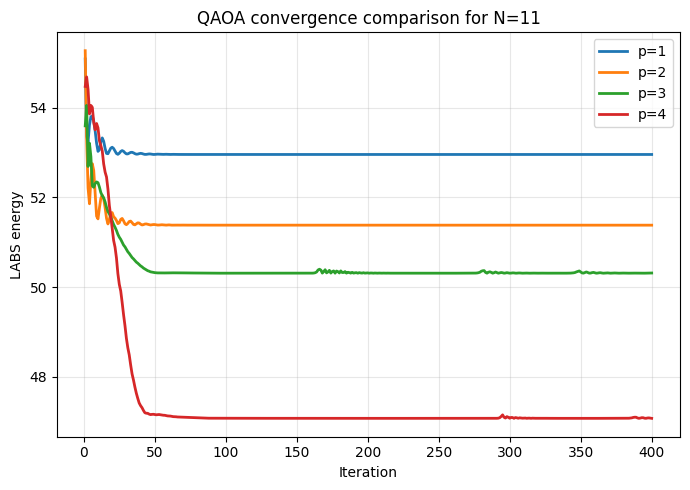

Testing QAOA optimization for N=13...
  Running with p=1 layers...
Final energy: 76.57580286186392
Best spin sequence: [ 1  1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1]
LABS energy (best spins): 22
Merit factor (best spins): 3.840909090909091
N_eval: 400
  Running with p=2 layers...
Final energy: 76.14724462974135
Best spin sequence: [ 1  1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1]
LABS energy (best spins): 22
Merit factor (best spins): 3.840909090909091
N_eval: 400
  Running with p=3 layers...
Final energy: 74.40615772135762
Best spin sequence: [ 1  1 -1  1 -1  1  1  1 -1  1 -1  1  1]
LABS energy (best spins): 90
Merit factor (best spins): 0.9388888888888889
N_eval: 400
  Running with p=4 layers...
Final energy: 75.1069140552481
Best spin sequence: [ 1  1 -1 -1  1 -1  1 -1  1 -1 -1  1  1]
LABS energy (best spins): 50
Merit factor (best spins): 1.69
N_eval: 400


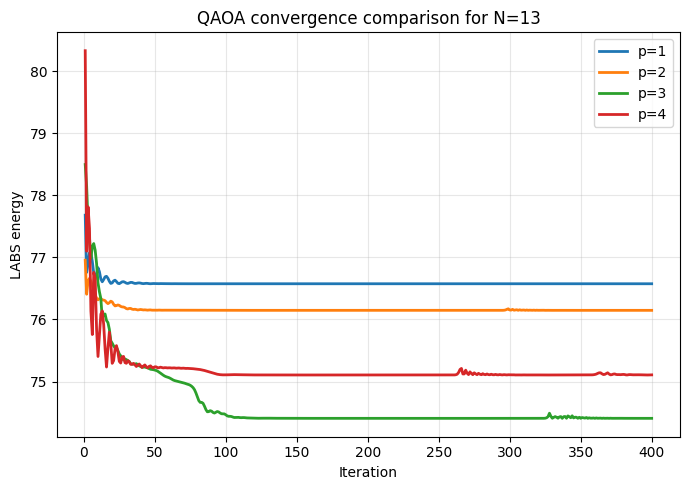

In [4]:
import dimod
import neal
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt


def _simplify_pauli_z_indices(indices):
    """Cancel repeated indices using Z_i^2 = I and return sorted unique indices."""
    parity = {}
    for idx in indices:
        parity[idx] = not parity.get(idx, False)
    return tuple(sorted(i for i, odd in parity.items() if odd))


def build_labs_cost_hamiltonian(N: int):
    """
    Build the LABS quartic cost Hamiltonian for QAOA.

    Returns:
        H: qml.Hamiltonian with 2- and 4-local Z terms
        constant: identity offset to be added back to energy/merit reporting
    """
    coeffs = {}
    constant = 0.0

    for k in range(1, N):
        for i in range(N - k):
            for j in range(N - k):
                term_indices = _simplify_pauli_z_indices((i, i + k, j, j + k))
                if len(term_indices) == 0:
                    constant += 1.0
                    continue
                coeffs[term_indices] = coeffs.get(term_indices, 0.0) + 1.0

    ops = []
    weights = []
    for term_indices, weight in coeffs.items():
        if len(term_indices) == 1:
            op = qml.PauliZ(term_indices[0])
        else:
            op = qml.prod(*[qml.PauliZ(i) for i in term_indices])
        ops.append(op)
        weights.append(weight)

    H = qml.Hamiltonian(weights, ops).simplify()
    return H, constant


def qaoa_cost_layer(gamma: float, H: qml.Hamiltonian):
    """Apply the LABS QAOA cost layer using PennyLane time evolution."""
    qml.ApproxTimeEvolution(H, gamma, 1)


def sample_qaoa_p_layers(
    N: int,
    p: int,
    gammas: np.ndarray,
    betas: np.ndarray,
    shots: int = 1000,
):
    """
    Sample bitstrings from p-layer LABS QAOA.

    Returns:
        samples: array of shape (shots, N) with bits in {0,1}
        constant: identity offset in the LABS Hamiltonian
    """
    if len(gammas) != p or len(betas) != p:
        raise ValueError("gammas and betas must have length p")

    H, constant = build_labs_cost_hamiltonian(N)
    dev = qml.device("default.qubit", wires=N, shots=shots)

    @qml.qnode(dev)
    def circuit():
        for i in range(N):
            qml.Hadamard(wires=i)
        for layer in range(p):
            qaoa_cost_layer(gammas[layer], H)
            for i in range(N):
                qml.RX(2 * betas[layer], wires=i)
        return qml.sample(wires=range(N))

    return circuit(), constant


def optimize_qaoa_and_plot(
    N: int,
    p: int,
    steps: int = 200,
    lr: float = 0.1,
    seed: int = 1234,
    show_plot: bool = True,
    save_plot: bool = True,
):
    """
    Optimize QAOA parameters for LABS and optionally save the convergence curve and data.
    """
    rng = np.random.default_rng(seed)
    H, constant = build_labs_cost_hamiltonian(N)
    dev = qml.device("default.qubit", wires=N)

    @qml.qnode(dev)
    def cost_fn(params):
        gammas = params[0]
        betas = params[1]
        for i in range(N):
            qml.Hadamard(wires=i)
        for layer in range(p):
            qaoa_cost_layer(gammas[layer], H)
            for i in range(N):
                qml.RX(2 * betas[layer], wires=i)
        return qml.expval(H)

    @qml.qnode(dev)
    def probs_fn(params):
        gammas = params[0]
        betas = params[1]
        for i in range(N):
            qml.Hadamard(wires=i)
        for layer in range(p):
            qaoa_cost_layer(gammas[layer], H)
            for i in range(N):
                qml.RX(2 * betas[layer], wires=i)
        return qml.probs(wires=range(N))

    init_params = rng.uniform(0, np.pi, size=(2, p))
    params = pnp.array(init_params, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=lr)

    history = []
    for _ in range(steps):
        params, cost = opt.step_and_cost(cost_fn, params)
        history.append(cost + constant)

    probs = probs_fn(params)
    best_index = int(pnp.argmax(probs))
    bitstring = format(best_index, f"0{N}b")
    best_spins = np.array([1 if b == "0" else -1 for b in bitstring], dtype=int)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history, lw=2)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("LABS energy")
    ax.set_title(f"QAOA convergence (N={N}, p={p})")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    filename_stem = f"labs_qaoa_N{N}_p{p}"
    if save_plot:
        save_run_results(
            filename_stem,
            history=history,
            metadata={
                "N": N,
                "p": p,
                "steps": steps,
                "N_eval": steps,
                "lr": lr,
                "seed": seed,
                "constant": float(constant),
                "best_spins": best_spins.tolist(),
                "best_energy": float(labs_cost_function(best_spins)),
                "merit_factor": float(merit_factor(best_spins)),
            },
            figure=fig,
        )
    if show_plot:
        plt.show()
    plt.close(fig)

    return {
        "params": params,
        "history": history,
        "constant": constant,
        "best_spins": best_spins,
        "N_eval": steps,
    }

# Test on N = 5
for N in [5, 11, 13]:
    print(f"Testing QAOA optimization for N={N}...")
    combined = []
    fig, ax = plt.subplots(figsize=(7, 5))
    for p in [1, 2, 3, 4]:
        print(f"  Running with p={p} layers...")
        result = optimize_qaoa_and_plot(N, p, steps=400, lr=0.005, seed=seed, show_plot=False, save_plot=True)
        combined.append(
            {
                "p": p,
                "N_eval": result["N_eval"],
                "final_energy": float(result["history"][-1]),
                "best_spins": result["best_spins"].tolist(),
                "best_energy": float(labs_cost_function(result["best_spins"])),
                "merit_factor": float(merit_factor(result["best_spins"])),
            }
        )
        ax.plot(range(1, len(result["history"]) + 1), result["history"], lw=2, label=f"p={p}")
        print("Final energy:", result["history"][-1])
        print("Best spin sequence:", result["best_spins"])
        print("LABS energy (best spins):", labs_cost_function(result["best_spins"]))
        print("Merit factor (best spins):", merit_factor(result["best_spins"]))
        print("N_eval:", result["N_eval"])

        if p == 4:
            qaoa_p4_result = result

    ax.set_xlabel("Iteration")
    ax.set_ylabel("LABS energy")
    ax.set_title(f"QAOA convergence comparison for N={N}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    save_run_results(
        f"labs_qaoa_N{N}_all_p",
        metadata={
            "N": N,
            "steps": 400,
            "N_eval": 400,
            "lr": 0.005,
            "seed": seed,
            "results": combined,
        },
        figure=fig,
    )
    plt.show()
    plt.close(fig)

Grid-search minimum:
beta  = 1.099557
gamma = 2.764602
<H_C> = 4.001930


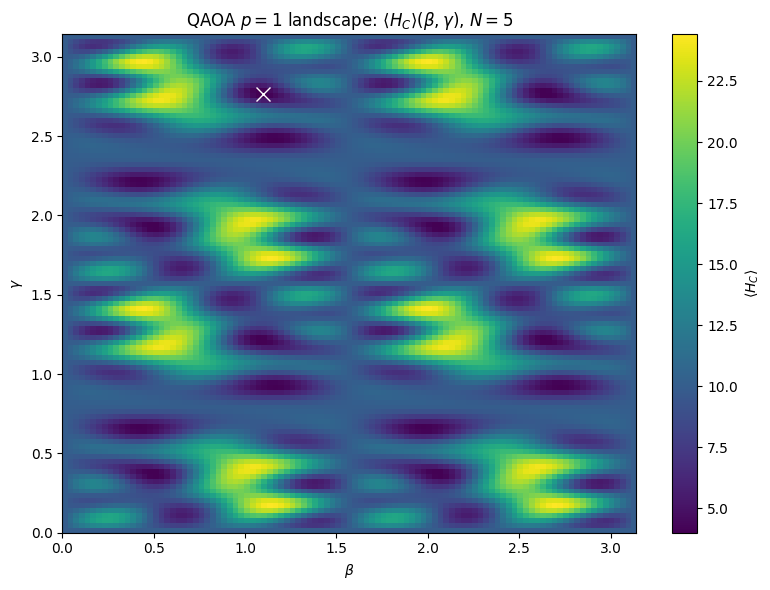

In [5]:
# QAOA landscape visualization (p=1)
import numpy as np
import matplotlib.pyplot as plt

# QAOA p=1 landscape using functions defined above
N = 5
num_beta = 101
num_gamma = 101
beta_range = (0.0, np.pi)
gamma_range = (0.0, np.pi)

H, constant = build_labs_cost_hamiltonian(N)

dev = qml.device("default.qubit", wires=N)

@qml.qnode(dev)
def cost_fn(beta, gamma):
    for i in range(N):
        qml.Hadamard(wires=i)
    qaoa_cost_layer(gamma, H)
    for i in range(N):
        qml.RX(2 * beta, wires=i)
    return qml.expval(H)

betas = np.linspace(beta_range[0], beta_range[1], num_beta)
gammas = np.linspace(gamma_range[0], gamma_range[1], num_gamma)
landscape = np.zeros((num_gamma, num_beta), dtype=np.float64)

for i, gamma in enumerate(gammas):
    for j, beta in enumerate(betas):
        landscape[i, j] = cost_fn(beta, gamma) + constant

min_index = np.unravel_index(np.argmin(landscape), landscape.shape)
beta_min = betas[min_index[1]]
gamma_min = gammas[min_index[0]]
value_min = landscape[min_index]

print("Grid-search minimum:")
print(f"beta  = {beta_min:.6f}")
print(f"gamma = {gamma_min:.6f}")
print(f"<H_C> = {value_min:.6f}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    landscape,
    origin="lower",
    aspect="auto",
    extent=[betas[0], betas[-1], gammas[0], gammas[-1]],
)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$\gamma$")
ax.set_title(rf"QAOA $p=1$ landscape: $\langle H_C \rangle(\beta,\gamma)$, $N={N}$")
ax.plot(beta_min, gamma_min, marker="x", markersize=10, color="white")
fig.colorbar(im, ax=ax, label=r"$\langle H_C \rangle$")
fig.tight_layout()

save_run_results(
    f"labs_landscape_N{N}",
    metadata={
        "N": N,
        "beta_min": float(beta_min),
        "gamma_min": float(gamma_min),
        "value_min": float(value_min),
    },
    figure=fig,
)

plt.show()
plt.close(fig)

## Advanced QAOA: constraint-preserving XY mixer


Testing constraint-preserving QAOA for N=5, k=4...
  Running with p=1 layers...
  Final energy: 2.000000
  Best bitstring: 11101
  Hamming weight: 4
  LABS energy: 2
  Merit factor: 6.250000
  N_eval: 400
  Running with p=2 layers...
  Final energy: 2.000000
  Best bitstring: 11101
  Hamming weight: 4
  LABS energy: 2
  Merit factor: 6.250000
  N_eval: 400
  Running with p=3 layers...
  Final energy: 2.000006
  Best bitstring: 11101
  Hamming weight: 4
  LABS energy: 2
  Merit factor: 6.250000
  N_eval: 400
  Running with p=4 layers...
  Final energy: 2.000000
  Best bitstring: 10111
  Hamming weight: 4
  LABS energy: 2
  Merit factor: 6.250000
  N_eval: 400


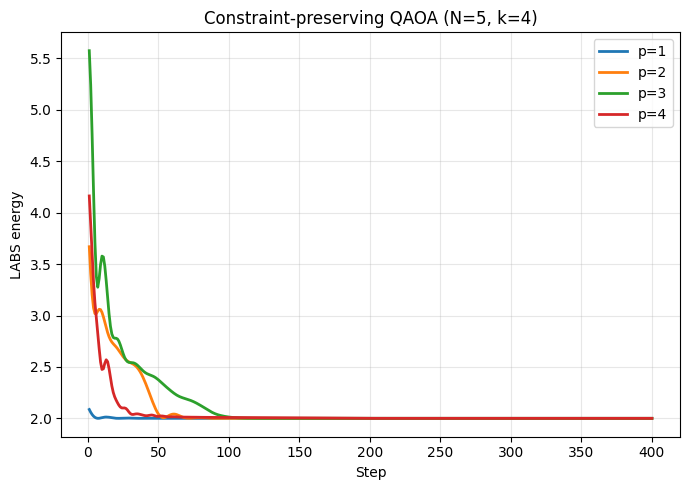


Testing constraint-preserving QAOA for N=11, k=5...
  Running with p=1 layers...
  Final energy: 33.000000
  Best bitstring: 01101010001
  Hamming weight: 5
  LABS energy: 33
  Merit factor: 1.833333
  N_eval: 400
  Running with p=2 layers...
  Final energy: 33.000000
  Best bitstring: 01101010001
  Hamming weight: 5
  LABS energy: 33
  Merit factor: 1.833333
  N_eval: 400
  Running with p=3 layers...
  Final energy: 46.166545
  Best bitstring: 01110100001
  Hamming weight: 5
  LABS energy: 25
  Merit factor: 2.420000
  N_eval: 400
  Running with p=4 layers...
  Final energy: 45.279760
  Best bitstring: 01111000010
  Hamming weight: 5
  LABS energy: 41
  Merit factor: 1.475610
  N_eval: 400


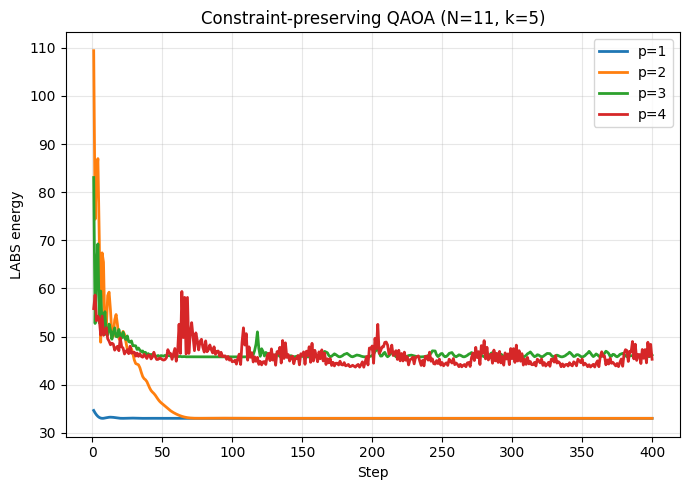


Testing constraint-preserving QAOA for N=13, k=9...
  Running with p=1 layers...
  Final energy: 78.293708
  Best bitstring: 0111111010101
  Hamming weight: 9
  LABS energy: 86
  Merit factor: 0.982558
  N_eval: 400
  Running with p=2 layers...
  Final energy: 38.000000
  Best bitstring: 1101101010111
  Hamming weight: 9
  LABS energy: 38
  Merit factor: 2.223684
  N_eval: 400
  Running with p=3 layers...
  Final energy: 38.000000
  Best bitstring: 1101101010111
  Hamming weight: 9
  LABS energy: 38
  Merit factor: 2.223684
  N_eval: 400
  Running with p=4 layers...
  Final energy: 52.389839
  Best bitstring: 0111111011001
  Hamming weight: 9
  LABS energy: 50
  Merit factor: 1.690000
  N_eval: 400


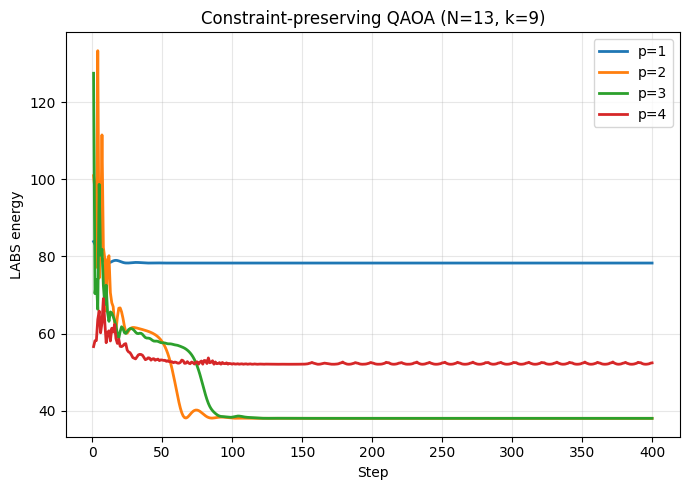

In [6]:
# Advanced QAOA: constraint-preserving XY mixer (fixed Hamming weight)
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt

def prepare_feasible_state(n: int, k: int):
    """Prepare a computational-basis state with exactly k ones."""
    for i in range(k):
        qml.PauliX(wires=i)

def ring_xy_partitions(n: int):
    """Return edge partitions for a ring XY mixer."""
    odd_edges = [(i, i + 1) for i in range(0, n - 1, 2)]
    even_edges = [(i, i + 1) for i in range(1, n - 1, 2)]
    partitions = [odd_edges, even_edges]
    if n % 2 == 1:
        partitions.append([(n - 1, 0)])
    return partitions

def xy_mixer_layer(beta: float, n: int):
    """Apply one constraint-preserving XY mixer layer on a ring."""
    for edges in ring_xy_partitions(n):
        for i, j in edges:
            qml.IsingXY(beta, wires=[i, j])

def qaoa_xy_cost_layer(gamma: float, H: qml.Hamiltonian):
    """Phase-separation unitary for the LABS cost Hamiltonian."""
    qml.ApproxTimeEvolution(H, gamma, 1)

def run_constraint_preserving_qaoa(
    n: int,
    k: int,
    p: int,
    steps: int = 400,
    lr: float = 0.1,
    seed: int = seed,
 ):
    """Optimize QAOA with a constraint-preserving XY mixer (fixed Hamming weight k)."""
    rng = np.random.default_rng(seed)
    H, constant = build_labs_cost_hamiltonian(n)
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def cost_fn(params):
        gammas = params[0]
        betas = params[1]
        prepare_feasible_state(n, k)
        for layer in range(p):
            qaoa_xy_cost_layer(gammas[layer], H)
            xy_mixer_layer(betas[layer], n)
        return qml.expval(H)

    @qml.qnode(dev)
    def probs_fn(params):
        gammas = params[0]
        betas = params[1]
        prepare_feasible_state(n, k)
        for layer in range(p):
            qaoa_xy_cost_layer(gammas[layer], H)
            xy_mixer_layer(betas[layer], n)
        return qml.probs(wires=range(n))

    init_params = rng.uniform(0, np.pi, size=(2, p))
    params = pnp.array(init_params, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=lr)

    history = []
    for _ in range(steps):
        params, cost = opt.step_and_cost(cost_fn, params)
        history.append(cost + constant)

    probs = probs_fn(params)
    best_index = int(pnp.argmax(probs))
    bitstring = format(best_index, f"0{n}b")
    best_spins = np.array([1 if b == "0" else -1 for b in bitstring], dtype=int)
    hamming_weight = bitstring.count("1")

    return {
        "params": params,
        "history": history,
        "best_spins": best_spins,
        "best_bitstring": bitstring,
        "hamming_weight": hamming_weight,
        "energy": labs_cost_function(best_spins),
        "merit_factor": merit_factor(best_spins),
        "N_eval": steps,
    }

# Demo: fixed Hamming weight k on a small instance
n_demo = [5, 11, 13]
k_demo = [4, 5, 9]
p_demo = [1, 2, 3, 4]

for n, k in zip(n_demo, k_demo):
    print(f"\nTesting constraint-preserving QAOA for N={n}, k={k}...")
    combined_xy = []
    fig_xy, ax_xy = plt.subplots(figsize=(7, 5))

    for p in p_demo:
        print(f"  Running with p={p} layers...")
        xy_result = run_constraint_preserving_qaoa(n, k, p, steps=400, lr=0.05, seed=seed)

        combined_xy.append({
            "p": p,
            "N_eval": xy_result["N_eval"],
            "final_energy": float(xy_result["history"][-1]),
            "best_bitstring": xy_result["best_bitstring"],
            "hamming_weight": xy_result["hamming_weight"],
            "labs_energy": float(xy_result["energy"]),
            "merit_factor": float(xy_result["merit_factor"]),
        })

        ax_xy.plot(range(1, len(xy_result["history"]) + 1), xy_result["history"],
                   lw=2, label=f"p={p}")
        print(f"  Final energy: {xy_result['history'][-1]:.6f}")
        print(f"  Best bitstring: {xy_result['best_bitstring']}")
        print(f"  Hamming weight: {xy_result['hamming_weight']}")
        print(f"  LABS energy: {xy_result['energy']}")
        print(f"  Merit factor: {xy_result['merit_factor']:.6f}")
        print(f"  N_eval: {xy_result['N_eval']}")

        # Save every p curve individually
        fig_xy_each, ax_xy_each = plt.subplots(figsize=(7, 5))
        ax_xy_each.plot(range(1, len(xy_result["history"]) + 1), xy_result["history"], lw=2, label=f"p={p}")
        ax_xy_each.set_xlabel("Step")
        ax_xy_each.set_ylabel("LABS energy")
        ax_xy_each.set_title(f"Constraint-preserving QAOA (N={n}, k={k}, p={p})")
        ax_xy_each.grid(True, alpha=0.3)
        ax_xy_each.legend()
        fig_xy_each.tight_layout()
        save_run_results(
            f"labs_qaoa_xy_N{n}_k{k}_p{p}",
            history=xy_result["history"],
            metadata={
                "method": "Constraint-preserving QAOA (XY mixer)",
                "n": n,
                "k": k,
                "p": p,
                "steps": 400,
                "N_eval": xy_result["N_eval"],
                "seed": seed,
                "best_bitstring": xy_result["best_bitstring"],
                "hamming_weight": xy_result["hamming_weight"],
                "labs_energy": float(xy_result["energy"]),
                "merit_factor": float(xy_result["merit_factor"]),
            },
            figure=fig_xy_each,
        )
        plt.close(fig_xy_each)

        if p == 4:
            qaoa_xy_p4_result = xy_result

    ax_xy.set_xlabel("Step")
    ax_xy.set_ylabel("LABS energy")
    ax_xy.set_title(f"Constraint-preserving QAOA (N={n}, k={k})")
    ax_xy.grid(True, alpha=0.3)
    ax_xy.legend()
    fig_xy.tight_layout()

    save_run_results(
        f"labs_qaoa_xy_N{n}_k{k}_all_p",
        metadata={
            "method": "Constraint-preserving QAOA (XY mixer)",
            "n": n,
            "k": k,
            "N_eval": 400,
            "results": combined_xy,
        },
        figure=fig_xy,
    )

    plt.show()
    plt.close(fig_xy)

### Strategy 2: Quadratization and Quantum Annealing
Here, we reduce the quartic problem to a quadratic one (QUBO) and solve it with a simulated quantum annealer. This is a common and powerful hybrid technique.

In [7]:
import numpy as np
import dimod
import neal
from collections import defaultdict

# ============================================================
# Build higher-order Ising model for LABS
# ============================================================

def simplify_spin_term(term):
    """
    Simplify products of spin variables using s_i^2 = 1.

    Example:
        s_0 s_1 s_0 s_2 = s_1 s_2

    Input:
        term: iterable of variable indices

    Output:
        sorted tuple of variables that remain
    """
    counts = defaultdict(int)

    for v in term:
        counts[v] += 1

    reduced = [v for v, c in counts.items() if c % 2 == 1]
    return tuple(sorted(reduced))


def build_labs_higher_order_ising(n):
    """
    Build the LABS objective as a higher-order Ising polynomial.

    The LABS energy is

        E(s) = sum_k (sum_i s_i s_{i+k})^2

    Expanding gives terms of the form

        s_i s_{i+k} s_j s_{j+k}

    which are generally quartic.

    Returns:
        polynomial: dict mapping tuples of variables to coefficients
                    compatible with dimod.make_quadratic
    """
    polynomial = defaultdict(float)

    for k in range(1, n):
        pairs = [(i, i + k) for i in range(n - k)]

        for a in range(len(pairs)):
            i, ip = pairs[a]

            for b in range(len(pairs)):
                j, jp = pairs[b]

                term = simplify_spin_term((i, ip, j, jp))
                polynomial[term] += 1.0

    return dict(polynomial)


# ============================================================
# Convert to BQM and run simulated annealing
# ============================================================

def solve_labs_with_simulated_annealing(
    n,
    num_reads=1000,
    num_sweeps=5000,
    strength=None,
    seed=seed,
):
    """
    Solve LABS using simulated annealing.

    Steps:
        1. Build higher-order Ising polynomial.
        2. Reduce it to a quadratic BQM using dimod.make_quadratic.
        3. Sample the BQM using neal.SimulatedAnnealingSampler.
        4. Evaluate the true LABS energy of returned samples.

    Args:
        n: sequence length
        num_reads: number of annealing runs
        num_sweeps: number of sweeps per run
        strength: penalty strength for quadratization
        seed: random seed

    Returns:
        Dictionary containing best solution and full sampleset.
    """
    polynomial = build_labs_higher_order_ising(n)

    if strength is None:
        # A conservative penalty strength.
        # Larger values enforce auxiliary constraints more strongly.
        strength = 10 * sum(abs(c) for c in polynomial.values())

    bqm = dimod.make_quadratic(
        polynomial,
        strength=strength,
        vartype=dimod.SPIN,
    )

    sampler = neal.SimulatedAnnealingSampler()

    sampleset = sampler.sample(
        bqm,
        num_reads=num_reads,
        num_sweeps=num_sweeps,
        seed=seed,
    )

    best_spins = None
    best_energy = None
    best_sample = None

    for sample, bqm_energy in sampleset.data(["sample", "energy"]):
        # Extract only the original LABS variables 0, 1, ..., n-1.
        spins = np.array([sample[i] for i in range(n)], dtype=int)

        true_energy = labs_cost_function(spins)

        if best_energy is None or true_energy < best_energy:
            best_energy = true_energy
            best_spins = spins
            best_sample = sample

    return {
        "n": n,
        "best_spins": best_spins,
        "best_bitstring": spins_to_bitstring(best_spins),
        "best_labs_energy": best_energy,
        "best_merit_factor": merit_factor(best_spins),
        "bqm": bqm,
        "sampleset": sampleset,
        "strength": strength,
        "num_variables": len(bqm.variables),
        "N_eval": num_reads,
        "num_reads": num_reads,
        "num_sweeps": num_sweeps,
    }


# ============================================================
# Utilities
# ============================================================

def spins_to_bitstring(spins):
    """
    Convert spins {-1, +1} to a bitstring.

    Convention:
        +1 -> 0
        -1 -> 1
    """
    bits = [0 if s == 1 else 1 for s in spins]
    return "".join(str(b) for b in bits)


def bitstring_to_spins(bitstring):
    """
    Convert bitstring to spins.

    Convention:
        0 -> +1
        1 -> -1
    """
    return np.array([1 if b == "0" else -1 for b in bitstring], dtype=int)

for n in [5, 11, 13]:

    result = solve_labs_with_simulated_annealing(
        n=n,
        num_reads=2000,
        num_sweeps=10000,
        seed=seed,
    )

    print("LABS simulated annealing result")
    print("--------------------------------")
    print(f"N: {result['n']}")
    print(f"Best spin sequence: {result['best_spins']}")
    print(f"Best bitstring: {result['best_bitstring']}")
    print(f"Best LABS energy: {result['best_labs_energy']}")
    print(f"Best merit factor: {result['best_merit_factor']:.6f}")
    print(f"Penalty strength: {result['strength']}")
    print(
        "Variables:",
        result["num_variables"],
    )
    print(f"N_eval: {result['N_eval']}")
    
    save_run_results(
        f"labs_sa_N{n}",
        metadata={
            "method": "Simulated Annealing",
            "n": n,
            "N_eval": result["N_eval"],
            "num_reads": result["num_reads"],
            "num_sweeps": result["num_sweeps"],
            "best_spins": result['best_spins'].tolist(),
            "best_bitstring": result['best_bitstring'],
            "best_labs_energy": float(result['best_labs_energy']),
            "best_merit_factor": float(result['best_merit_factor']),
            "penalty_strength": float(result['strength']),
            "num_variables": result['num_variables'],
        },
    )

LABS simulated annealing result
--------------------------------
N: 5
Best spin sequence: [-1  1 -1 -1 -1]
Best bitstring: 10111
Best LABS energy: 2
Best merit factor: 6.250000
Penalty strength: 300.0
Variables: 11
N_eval: 2000
LABS simulated annealing result
--------------------------------
N: 11
Best spin sequence: [ 1 -1  1  1 -1  1  1  1 -1 -1 -1]
Best bitstring: 01001000111
Best LABS energy: 5
Best merit factor: 12.100000
Penalty strength: 3850.0
Variables: 91
N_eval: 2000
LABS simulated annealing result
--------------------------------
N: 13
Best spin sequence: [-1  1  1 -1 -1  1  1  1  1  1 -1  1 -1]
Best bitstring: 1001100000101
Best LABS energy: 14
Best merit factor: 6.035714
Penalty strength: 6500.0
Variables: 141
N_eval: 2000


### Strategy 3: Variational Quantum Eigensolver (VQE)
This uses a flexible, hardware-efficient ansatz to find the ground state of the quartic Hamiltonian. Like QAOA, this is demonstrated on a small `N`.

Testing VQE for N=5...
  Running VQE with layers=1...
  Final cost (LABS energy): 2.000000
  LABS energy: 2
  Merit factor: 6.250000
  Time: 2.81s
  N_eval: 400
  Running VQE with layers=2...
  Final cost (LABS energy): 2.000081
  LABS energy: 2
  Merit factor: 6.250000
  Time: 5.02s
  N_eval: 400
  Running VQE with layers=3...
  Final cost (LABS energy): 2.002146
  LABS energy: 2
  Merit factor: 6.250000
  Time: 6.68s
  N_eval: 400
  Running VQE with layers=4...
  Final cost (LABS energy): 2.001328
  LABS energy: 2
  Merit factor: 6.250000
  Time: 8.57s
  N_eval: 400


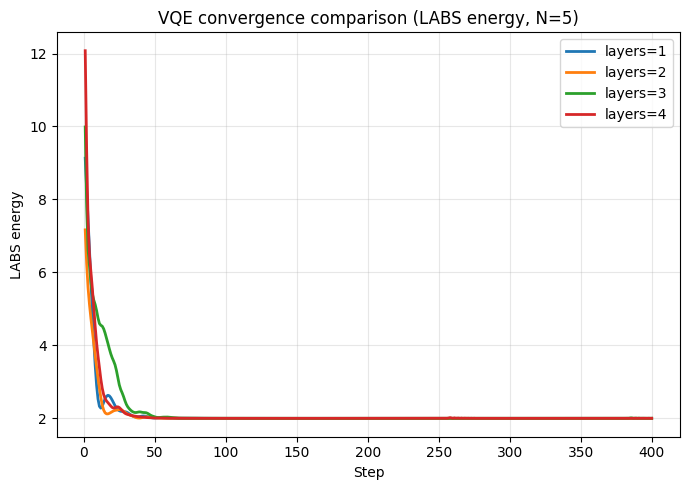

Testing VQE for N=11...
  Running VQE with layers=1...
  Final cost (LABS energy): 21.000000
  LABS energy: 21
  Merit factor: 2.880952
  Time: 19.22s
  N_eval: 400
  Running VQE with layers=2...
  Final cost (LABS energy): 17.000015
  LABS energy: 5
  Merit factor: 12.100000
  Time: 23.82s
  N_eval: 400
  Running VQE with layers=3...
  Final cost (LABS energy): 13.000044
  LABS energy: 13
  Merit factor: 4.653846
  Time: 29.21s
  N_eval: 400
  Running VQE with layers=4...
  Final cost (LABS energy): 23.002577
  LABS energy: 25
  Merit factor: 2.420000
  Time: 34.06s
  N_eval: 400


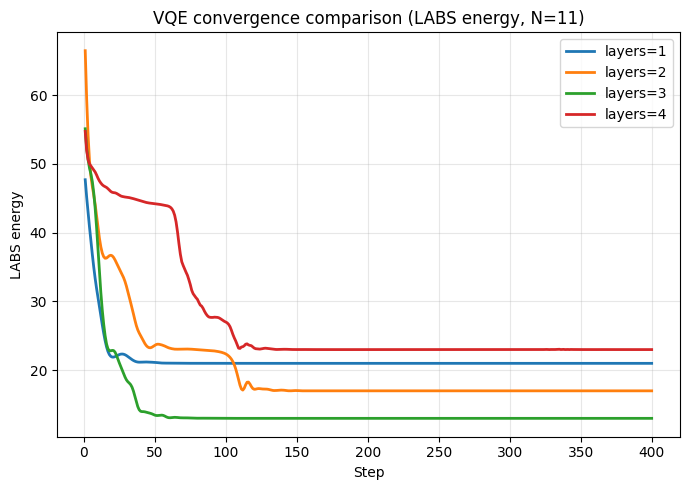

Testing VQE for N=13...
  Running VQE with layers=1...
  Final cost (LABS energy): 22.000000
  LABS energy: 22
  Merit factor: 3.840909
  Time: 43.77s
  N_eval: 400
  Running VQE with layers=2...
  Final cost (LABS energy): 22.001681
  LABS energy: 22
  Merit factor: 3.840909
  Time: 49.92s
  N_eval: 400
  Running VQE with layers=3...
  Final cost (LABS energy): 40.005559
  LABS energy: 30
  Merit factor: 2.816667
  Time: 57.34s
  N_eval: 400
  Running VQE with layers=4...
  Final cost (LABS energy): 36.016027
  LABS energy: 46
  Merit factor: 1.836957
  Time: 65.58s
  N_eval: 400


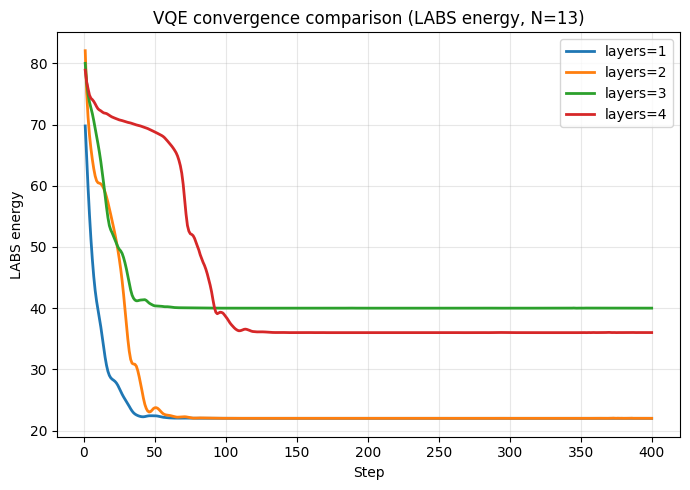

In [8]:
import pennylane as qml
from pennylane import numpy as pnp
import time

def run_vqe(N, layers, steps, lr, seed=seed):
    """Runs VQE with a hardware-efficient ansatz, tracking convergence history."""

    dev = qml.device("default.qubit", wires=N)
    H, constant = build_labs_cost_hamiltonian(N)
    rng = np.random.default_rng(seed)

    @qml.qnode(dev)
    def cost_fn(params):
        qml.StronglyEntanglingLayers(params, wires=range(N))
        return qml.expval(H)

    param_shape = qml.StronglyEntanglingLayers.shape(n_layers=layers, n_wires=N)
    init_params = rng.uniform(0, 2 * np.pi, size=param_shape)
    params = pnp.array(init_params, requires_grad=True)

    opt = qml.AdamOptimizer(stepsize=lr)

    history = []
    t0 = time.time()
    for i in range(steps):
        params, cost = opt.step_and_cost(cost_fn, params)
        history.append(float(cost + constant))
    t_elapsed = time.time() - t0

    # Get final bitstring
    @qml.qnode(dev)
    def get_probs(params):
        qml.StronglyEntanglingLayers(params, wires=range(N))
        return qml.probs(wires=range(N))

    probs = get_probs(params)
    best_idx = pnp.argmax(probs)
    binary_string = format(best_idx, f'0{N}b')
    s_vqe = np.array([1 if b == '0' else -1 for b in binary_string], dtype=int)

    return {
        'method': f'VQE (layers={layers})',
        'sequence': s_vqe,
        'energy': labs_cost_function(s_vqe),
        'merit_factor': merit_factor(s_vqe),
        'time': t_elapsed,
        'n_eval': steps,
        'history': history,
        'final_cost': history[-1] if history else None,
        'constant': float(constant),
        'seed': seed,
    }

for N in [5, 11, 13]:
    print(f"Testing VQE for N={N}...")
    combined_vqe = []
    fig_vqe, ax_vqe = plt.subplots(figsize=(7, 5))

    for p in [1, 2, 3, 4]:
        print(f"  Running VQE with layers={p}...")
        vqe_result = run_vqe(N=N, layers=p, steps=400, lr=0.1, seed=seed)
        if vqe_result:
            combined_vqe.append({
                "layers": p,
                "N_eval": vqe_result["n_eval"],
                "final_cost": float(vqe_result['final_cost']),
                "labs_energy": float(vqe_result['energy']),
                "merit_factor": float(vqe_result['merit_factor']),
                "time": float(vqe_result['time']),
                "sequence": vqe_result['sequence'].tolist(),
            })

            ax_vqe.plot(range(1, len(vqe_result['history']) + 1), vqe_result['history'],
                       lw=2, label=f"layers={p}")
            print(f"  Final cost (LABS energy): {vqe_result['final_cost']:.6f}")
            print(f"  LABS energy: {vqe_result['energy']}")
            print(f"  Merit factor: {vqe_result['merit_factor']:.6f}")
            print(f"  Time: {vqe_result['time']:.2f}s")
            print(f"  N_eval: {vqe_result['n_eval']}")

            # Save every layers=p curve individually
            fig_vqe_each, ax_vqe_each = plt.subplots(figsize=(7, 5))
            ax_vqe_each.plot(range(1, len(vqe_result['history']) + 1), vqe_result['history'], lw=2, label=f"layers={p}")
            ax_vqe_each.set_xlabel("Step")
            ax_vqe_each.set_ylabel("LABS energy")
            ax_vqe_each.set_title(f"VQE convergence (N={N}, layers={p})")
            ax_vqe_each.grid(True, alpha=0.3)
            ax_vqe_each.legend()
            fig_vqe_each.tight_layout()
            save_run_results(
                f"labs_vqe_N{N}_layers{p}",
                history=vqe_result['history'],
                metadata={
                    "method": "VQE (Hardware-efficient ansatz)",
                    "N": N,
                    "layers": p,
                    "N_eval": vqe_result["n_eval"],
                    "steps": 400,
                    "seed": seed,
                    "best_sequence": vqe_result['sequence'].tolist(),
                    "best_labs_energy": float(vqe_result['energy']),
                    "best_merit_factor": float(vqe_result['merit_factor']),
                },
                figure=fig_vqe_each,
            )
            plt.close(fig_vqe_each)

            if p == 4:
                vqe_p4_result = vqe_result

    ax_vqe.set_xlabel("Step")
    ax_vqe.set_ylabel("LABS energy")
    ax_vqe.set_title(f"VQE convergence comparison (LABS energy, N={N})")
    ax_vqe.grid(True, alpha=0.3)
    ax_vqe.legend()
    fig_vqe.tight_layout()

    save_run_results(
        f"labs_vqe_N{N}_all_layers",
        metadata={
            "method": "VQE (Hardware-efficient ansatz)",
            "N": N,
            "N_eval": 400,
            "seed": seed,
            "results": combined_vqe,
        },
        figure=fig_vqe,
    )

    plt.show()
    plt.close(fig_vqe)


FINAL COMPARISON: Best p/layers for Each Method (N=5)
QAOA best p: 2 (E = 2.00)
XY-QAOA best p: 1 (E = 2.00)
VQE best layers: 1 (E = 2.00)


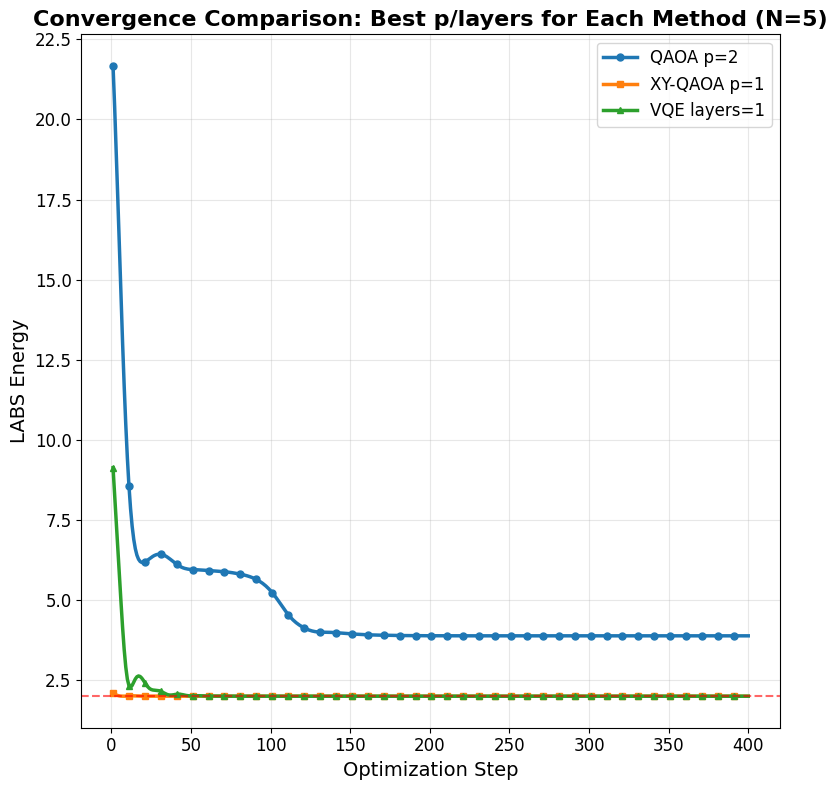

Summary:
  QAOA p=2             Final Energy = 3.884291, Steps = 400
  XY-QAOA p=1          Final Energy = 2.000000, Steps = 400
  VQE layers=1         Final Energy = 2.000000, Steps = 400

FINAL COMPARISON: Best p/layers for Each Method (N=11)
QAOA best p: 1 (E = 21.00)
XY-QAOA best p: 3 (E = 25.00)
VQE best layers: 2 (E = 5.00)


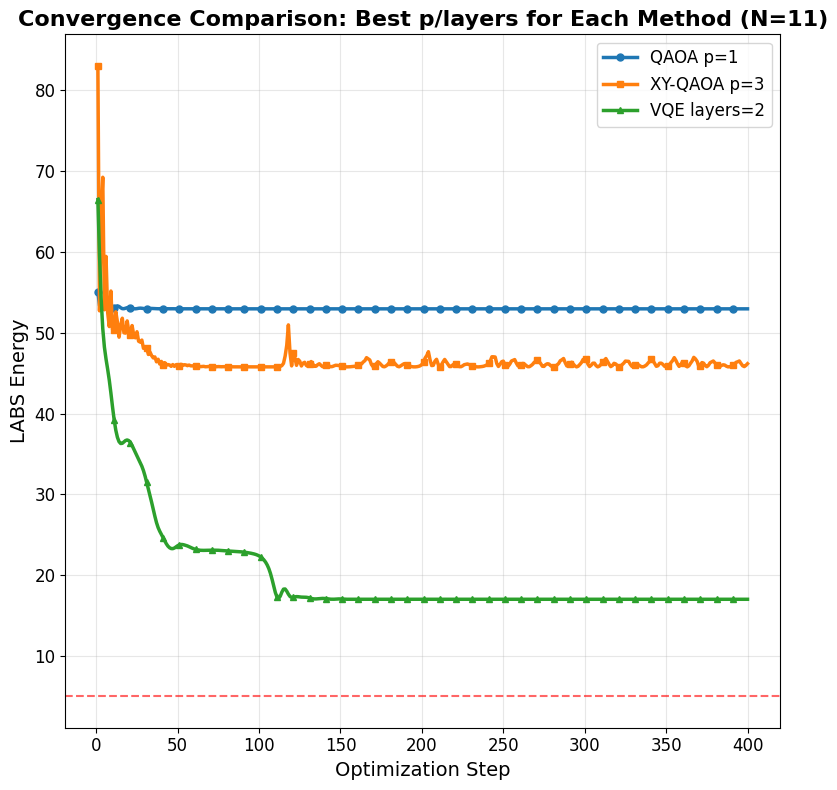

Summary:
  QAOA p=1             Final Energy = 52.957768, Steps = 400
  XY-QAOA p=3          Final Energy = 46.166545, Steps = 400
  VQE layers=2         Final Energy = 17.000015, Steps = 400

FINAL COMPARISON: Best p/layers for Each Method (N=13)
QAOA best p: 1 (E = 22.00)
XY-QAOA best p: 2 (E = 38.00)
VQE best layers: 1 (E = 22.00)


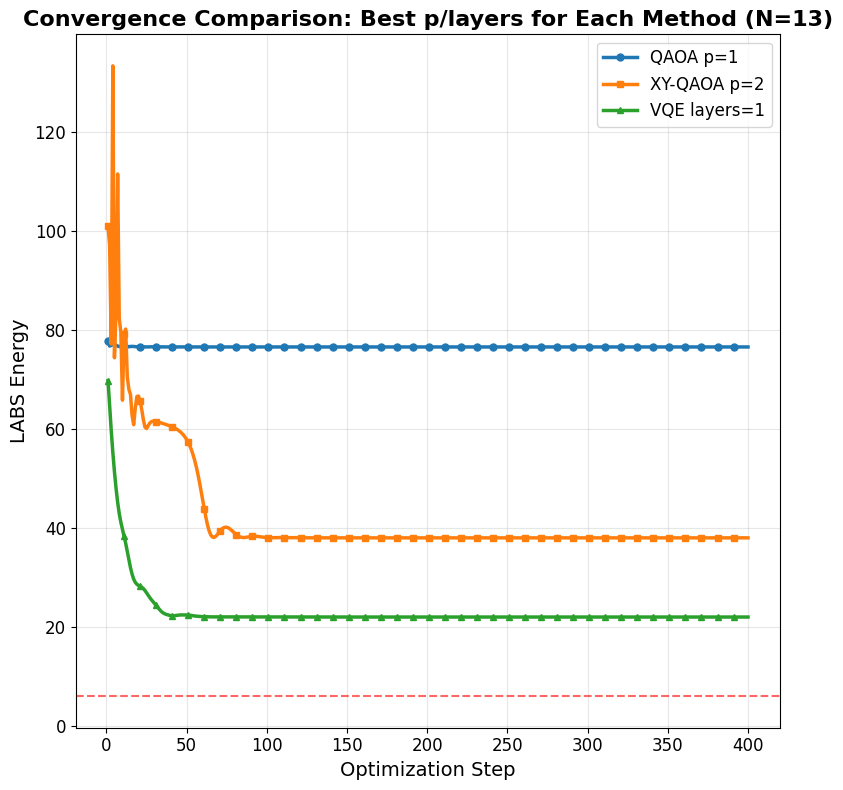

Summary:
  QAOA p=1             Final Energy = 76.575803, Steps = 400
  XY-QAOA p=2          Final Energy = 38.000000, Steps = 400
  VQE layers=1         Final Energy = 22.000000, Steps = 400


In [10]:
# Final Comparison Plot: Find and plot the best p/layers for each method across all N
import json

for target_N in [5, 11, 13]:
    print(f"\n{'='*70}")
    print(f"FINAL COMPARISON: Best p/layers for Each Method (N={target_N})")
    print(f"{'='*70}")
    
    # Function to find best p from aggregate JSON
    def find_best_p_from_aggregate(filename):
        """Load aggregate JSON and find p with best (lowest) energy."""
        try:
            with open(RESULTS_DIR / filename, "r") as f:
                data = json.load(f)
            best_p = None
            best_energy = float('inf')
            for result in data.get("results", []):
                energy = result.get("best_energy") or result.get("labs_energy")
                p_val = result.get("p") or result.get("layers")
                if energy < best_energy:
                    best_energy = energy
                    best_p = p_val
            return best_p, best_energy
        except Exception as e:
            print(f"  Could not load {filename}: {e}")
            return None, None
    
    # Find best p for QAOA
    qaoa_p, qaoa_e = find_best_p_from_aggregate(f"labs_qaoa_N{target_N}_all_p.json")
    
    # Find best p for XY-QAOA (need to determine k first)
    k_map = {5: 4, 11: 5, 13: 9}
    k = k_map.get(target_N)
    qaoa_xy_p, qaoa_xy_e = find_best_p_from_aggregate(f"labs_qaoa_xy_N{target_N}_k{k}_all_p.json") if k else (None, None)
    
    # Find best layers for VQE
    vqe_p, vqe_e = find_best_p_from_aggregate(f"labs_vqe_N{target_N}_all_layers.json")
    
    print(f"QAOA best p: {qaoa_p} (E = {qaoa_e:.2f})")
    print(f"XY-QAOA best p: {qaoa_xy_p} (E = {qaoa_xy_e:.2f})")
    print(f"VQE best layers: {vqe_p} (E = {vqe_e:.2f})")
    
    # Load and plot the best histories
    fig_comparison, ax_comparison = plt.subplots(figsize=(8, 8))  # square figure
    
    methods = []
    histories = []
    labels = []
    
    # Load QAOA
    if qaoa_p is not None:
        try:
            with open(RESULTS_DIR / f"labs_qaoa_N{target_N}_p{qaoa_p}.json", "r") as f:
                qaoa_data = json.load(f)
                qaoa_history = qaoa_data.get("history", [])
                methods.append("QAOA")
                histories.append(qaoa_history)
                labels.append(f"QAOA p={qaoa_p}")
        except Exception as e:
            print(f"  Error loading QAOA: {e}")
    
    # Load XY-QAOA
    if qaoa_xy_p is not None and k:
        try:
            with open(RESULTS_DIR / f"labs_qaoa_xy_N{target_N}_k{k}_p{qaoa_xy_p}.json", "r") as f:
                qaoa_xy_data = json.load(f)
                qaoa_xy_history = qaoa_xy_data.get("history", [])
                methods.append("XY-QAOA")
                histories.append(qaoa_xy_history)
                labels.append(f"XY-QAOA p={qaoa_xy_p}")
        except Exception as e:
            print(f"  Error loading XY-QAOA: {e}")
    
    # Load VQE
    if vqe_p is not None:
        try:
            with open(RESULTS_DIR / f"labs_vqe_N{target_N}_layers{vqe_p}.json", "r") as f:
                vqe_data = json.load(f)
                vqe_history = vqe_data.get("history", [])
                methods.append("VQE")
                histories.append(vqe_history)
                labels.append(f"VQE layers={vqe_p}")
        except Exception as e:
            print(f"  Error loading VQE: {e}")
    
    # Plot all curves with larger markers and lines
    markers = ['o', 's', '^']
    colors = ['C0', 'C1', 'C2']
    for i, (history, label) in enumerate(zip(histories, labels)):
        ax_comparison.plot(range(1, len(history) + 1), history, lw=2.5, label=label, 
                          marker=markers[i], markersize=5, markevery=10, color=colors[i])
    
    # Improve font sizes and layout
    ax_comparison.set_xlabel("Optimization Step", fontsize=14)
    ax_comparison.set_ylabel("LABS Energy", fontsize=14)
    ax_comparison.set_title(f"Convergence Comparison: Best p/layers for Each Method (N={target_N})", 
                           fontsize=16, fontweight='bold')
    ax_comparison.legend(fontsize=12, loc='best')
    ax_comparison.grid(True, alpha=0.3)
    ax_comparison.tick_params(axis='both', which='major', labelsize=12)
    
    # Add optimal energy line
    if target_N == 5:
        optimal_E = 2.0
    elif target_N == 11:
        optimal_E = 5.0
    else:  # N=13
        optimal_E = 6.0
    ax_comparison.axhline(y=optimal_E, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"comparison_best_p_N{target_N}.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Summary:")
    for method, hist in zip(labels, histories):
        if hist:
            print(f"  {method:20s} Final Energy = {hist[-1]:.6f}, Steps = {len(hist)}")
        else:
            print(f"  {method:20s} No data")
    print(f"{'='*70}")